# EPL Match Outcome Predictor

Predicting English Premier League match outcomes using historical data from 1993 to 2023. This project covers exploratory data analysis, SQL queries, feature engineering, classification, regression, clustering, and time series analysis across 12,026 matches spanning 31 seasons.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load and Explore

In [2]:
df = pd.read_csv('../data/raw/premier-league-matches.csv')
df['Date'] = pd.to_datetime(df['Date'])

print('Shape:', df.shape)
print('Seasons:', df['Season_End_Year'].min(), 'to', df['Season_End_Year'].max())
print('Teams:', df['Home'].nunique())
print('Missing values:', df.isna().sum().sum())
df.head(10)

Shape: (12026, 8)
Seasons: 1993 to 2023
Teams: 50
Missing values: 0


,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A
5,1993,1,1992-08-15,Ipswich Town,1,1,Aston Villa,D
6,1993,1,1992-08-15,Everton,1,1,Sheffield Weds,D
7,1993,1,1992-08-15,Southampton,0,0,Tottenham,D
8,1993,1,1992-08-15,Chelsea,1,1,Oldham Athletic,D
9,1993,1,1992-08-16,Nott'ham Forest,1,0,Liverpool,H


In [3]:
# Result distribution
ftr_counts = df['FTR'].value_counts()
ftr_pct = df['FTR'].value_counts(normalize=True).round(3) * 100
result_summary = pd.DataFrame({'Count': ftr_counts, 'Percent': ftr_pct})
result_summary.index = result_summary.index.map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})
print('Full-time result breakdown:')
result_summary

Full-time result breakdown:


,Count,Percent
FTR,,
Home Win,5519,45.9
Away Win,3410,28.4
Draw,3097,25.8


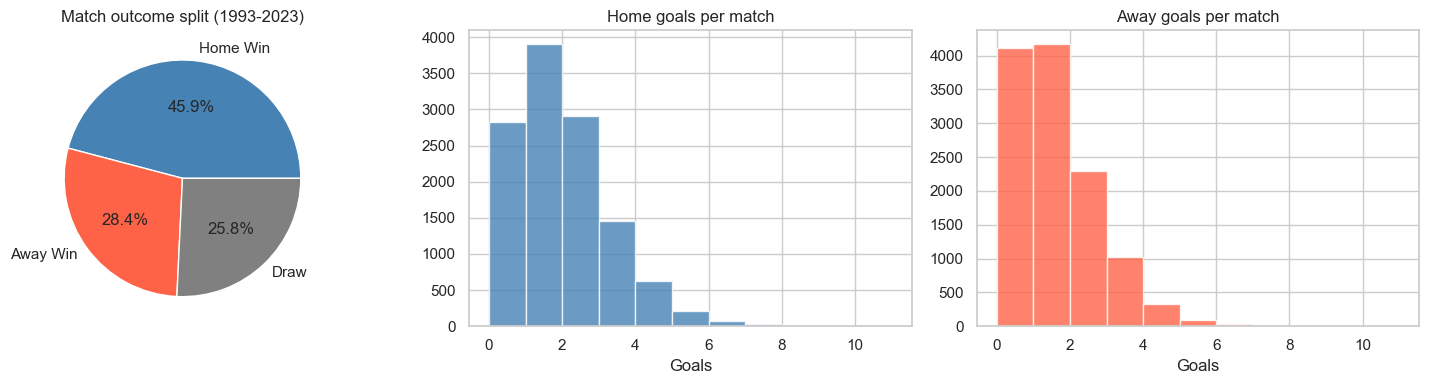

Average home goals: 1.52
Average away goals: 1.14
Average total goals per match: 2.67


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ftr_vals = df['FTR'].value_counts()[['H', 'A', 'D']].values
axes[0].pie(ftr_vals, labels=['Home Win', 'Away Win', 'Draw'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato', 'gray'])
axes[0].set_title('Match outcome split (1993-2023)')

axes[1].hist(df['HomeGoals'], bins=range(0, 12), color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Goals')
axes[1].set_title('Home goals per match')

axes[2].hist(df['AwayGoals'], bins=range(0, 12), color='tomato', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Goals')
axes[2].set_title('Away goals per match')

plt.tight_layout()
plt.show()

print(f"Average home goals: {df['HomeGoals'].mean():.2f}")
print(f"Average away goals: {df['AwayGoals'].mean():.2f}")
print(f"Average total goals per match: {(df['HomeGoals'] + df['AwayGoals']).mean():.2f}")

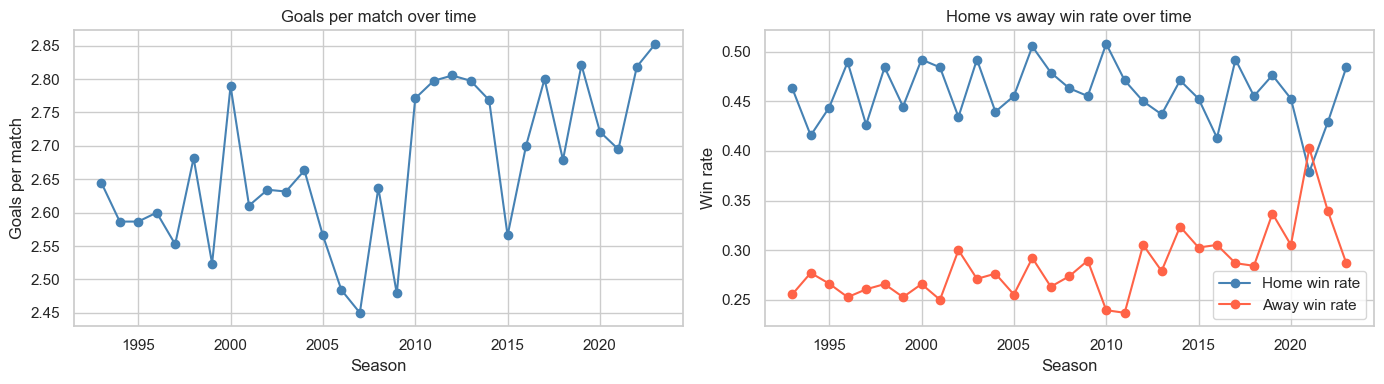

In [5]:
# Seasonal trends
seasonal = df.groupby('Season_End_Year').agg(
    matches=('FTR', 'count'),
    home_goals=('HomeGoals', 'sum'),
    away_goals=('AwayGoals', 'sum'),
    home_wins=('FTR', lambda x: (x == 'H').sum()),
    away_wins=('FTR', lambda x: (x == 'A').sum()),
).reset_index()
seasonal['goals_per_match'] = (seasonal['home_goals'] + seasonal['away_goals']) / seasonal['matches']
seasonal['home_win_rate'] = seasonal['home_wins'] / seasonal['matches']
seasonal['away_win_rate'] = seasonal['away_wins'] / seasonal['matches']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(seasonal['Season_End_Year'], seasonal['goals_per_match'], marker='o', linewidth=1.5, color='steelblue')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Goals per match')
axes[0].set_title('Goals per match over time')

axes[1].plot(seasonal['Season_End_Year'], seasonal['home_win_rate'], marker='o', label='Home win rate', color='steelblue')
axes[1].plot(seasonal['Season_End_Year'], seasonal['away_win_rate'], marker='o', label='Away win rate', color='tomato')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Win rate')
axes[1].set_title('Home vs away win rate over time')
axes[1].legend()

plt.tight_layout()
plt.show()

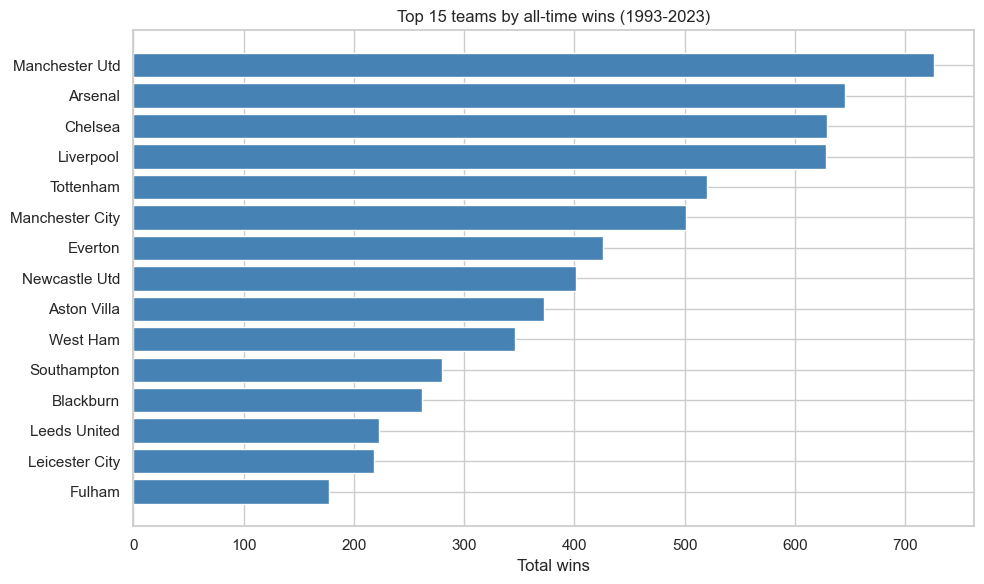

In [6]:
# Top 15 teams by all-time wins
home_wins = df[df['FTR'] == 'H'].groupby('Home').size().rename('home_wins')
away_wins = df[df['FTR'] == 'A'].groupby('Away').size().rename('away_wins')
team_wins = pd.concat([home_wins, away_wins], axis=1).fillna(0)
team_wins['total_wins'] = team_wins['home_wins'] + team_wins['away_wins']
team_wins = team_wins.sort_values('total_wins', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(team_wins.index, team_wins['total_wins'], color='steelblue')
plt.xlabel('Total wins')
plt.title('Top 15 teams by all-time wins (1993-2023)')
plt.tight_layout()
plt.show()

## 3. SQL Analysis

I load the match data into a SQLite database and run SQL queries to answer specific questions.

In [7]:
conn = sqlite3.connect('../data/processed/epl.db')
df.to_sql('matches', conn, if_exists='replace', index=False)
print('Table loaded. Row count:')
pd.read_sql('SELECT COUNT(*) AS total_matches FROM matches', conn)

Table loaded. Row count:


,total_matches
0,12026


In [8]:
# Goals and matches by decade
query = '''
SELECT
    CASE
        WHEN Season_End_Year BETWEEN 1993 AND 2002 THEN '1993-2002'
        WHEN Season_End_Year BETWEEN 2003 AND 2012 THEN '2003-2012'
        ELSE '2013-2023'
    END AS decade,
    COUNT(*) AS matches,
    SUM(HomeGoals + AwayGoals) AS total_goals,
    ROUND(AVG(HomeGoals + AwayGoals), 2) AS avg_goals_per_match
FROM matches
GROUP BY decade
ORDER BY decade
'''
print('Goals by decade:')
pd.read_sql(query, conn)

Goals by decade:


,decade,matches,total_goals,avg_goals_per_match
0,1993-2002,4046,10601,2.62
1,2003-2012,3800,9988,2.63
2,2013-2023,4180,11483,2.75


In [9]:
# Top 10 teams by total wins
query = '''
SELECT team, SUM(wins) AS total_wins
FROM (
    SELECT Home AS team, COUNT(*) AS wins FROM matches WHERE FTR = 'H' GROUP BY Home
    UNION ALL
    SELECT Away AS team, COUNT(*) AS wins FROM matches WHERE FTR = 'A' GROUP BY Away
) combined
GROUP BY team
ORDER BY total_wins DESC
LIMIT 10
'''
pd.read_sql(query, conn)

,team,total_wins
0,Manchester Utd,726
1,Arsenal,645
2,Chelsea,629
3,Liverpool,628
4,Tottenham,520
5,Manchester City,501
6,Everton,426
7,Newcastle Utd,401
8,Aston Villa,372
9,West Ham,346


In [10]:
# Home advantage overall
query = '''
SELECT
    ROUND(100.0 * SUM(CASE WHEN FTR = 'H' THEN 1 ELSE 0 END) / COUNT(*), 1) AS home_win_pct,
    ROUND(100.0 * SUM(CASE WHEN FTR = 'A' THEN 1 ELSE 0 END) / COUNT(*), 1) AS away_win_pct,
    ROUND(100.0 * SUM(CASE WHEN FTR = 'D' THEN 1 ELSE 0 END) / COUNT(*), 1) AS draw_pct
FROM matches
'''
pd.read_sql(query, conn)

,home_win_pct,away_win_pct,draw_pct
0,45.9,28.4,25.8


In [11]:
# Highest scoring seasons
query = '''
SELECT
    Season_End_Year,
    COUNT(*) AS matches,
    SUM(HomeGoals + AwayGoals) AS total_goals,
    ROUND(AVG(HomeGoals + AwayGoals), 2) AS avg_goals_per_match
FROM matches
GROUP BY Season_End_Year
ORDER BY avg_goals_per_match DESC
LIMIT 10
'''
pd.read_sql(query, conn)

,Season_End_Year,matches,total_goals,avg_goals_per_match
0,2023,380,1084,2.85
1,2022,380,1071,2.82
2,2019,380,1072,2.82
3,2012,380,1066,2.81
4,2017,380,1064,2.80
5,2013,380,1063,2.80
6,2011,380,1063,2.80
7,2000,380,1060,2.79
8,2014,380,1052,2.77
9,2010,380,1053,2.77


## 4. Feature Engineering

The raw dataset only has goals and results. To predict a match outcome I need to know each team's recent form going in. I build rolling statistics from the last 5 matches per team — goals scored, goals conceded, win rate, and draw rate — then check distributions, apply log transforms where needed, scale the features, and use PCA to visualize how well the classes separate.

In [ ]:
# Build team-centric view: each match becomes 2 rows, one per team
home_view = df[['Date', 'Home', 'HomeGoals', 'AwayGoals', 'FTR']].copy()
home_view.columns = ['Date', 'Team', 'goals_scored', 'goals_conceded', 'FTR_raw']
home_view['Win'] = (home_view['FTR_raw'] == 'H').astype(int)
home_view['Draw'] = (home_view['FTR_raw'] == 'D').astype(int)

away_view = df[['Date', 'Away', 'AwayGoals', 'HomeGoals', 'FTR']].copy()
away_view.columns = ['Date', 'Team', 'goals_scored', 'goals_conceded', 'FTR_raw']
away_view['Win'] = (away_view['FTR_raw'] == 'A').astype(int)
away_view['Draw'] = (away_view['FTR_raw'] == 'D').astype(int)

team_matches = pd.concat([home_view, away_view]).sort_values(['Team', 'Date']).reset_index(drop=True)

# Rolling 5-match stats per team — shift(1) so current match is never included
for col in ['goals_scored', 'goals_conceded', 'Win', 'Draw']:
    team_matches[f'roll_{col}'] = (
        team_matches.groupby('Team')[col]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

print('Sample — Arsenal rolling stats:')
team_matches[team_matches['Team'] == 'Arsenal'][
    ['Date', 'goals_scored', 'goals_conceded', 'Win', 'roll_goals_scored', 'roll_goals_conceded', 'roll_Win']
].head(8)

In [ ]:
# Merge rolling stats back to match level for home and away teams
home_stats = team_matches[['Date', 'Team', 'roll_goals_scored', 'roll_goals_conceded', 'roll_Win', 'roll_Draw']].copy()
home_stats.columns = ['Date', 'Home', 'home_avg_scored', 'home_avg_conceded', 'home_win_rate', 'home_draw_rate']

away_stats = team_matches[['Date', 'Team', 'roll_goals_scored', 'roll_goals_conceded', 'roll_Win', 'roll_Draw']].copy()
away_stats.columns = ['Date', 'Away', 'away_avg_scored', 'away_avg_conceded', 'away_win_rate', 'away_draw_rate']

features = df.merge(home_stats, on=['Date', 'Home'], how='left')
features = features.merge(away_stats, on=['Date', 'Away'], how='left')

# Difference features: how much stronger is the home team vs the away team right now
features['win_rate_diff'] = features['home_win_rate'] - features['away_win_rate']
features['scoring_diff'] = features['home_avg_scored'] - features['away_avg_scored']
features['conceding_diff'] = features['home_avg_conceded'] - features['away_avg_conceded']

# Target column: 0 = Home Win, 1 = Draw, 2 = Away Win
features['Result'] = features['FTR'].map({'H': 0, 'D': 1, 'A': 2})

feature_cols = [
    'home_avg_scored', 'home_avg_conceded', 'home_win_rate', 'home_draw_rate',
    'away_avg_scored', 'away_avg_conceded', 'away_win_rate', 'away_draw_rate',
    'win_rate_diff', 'scoring_diff', 'conceding_diff'
]

features = features.dropna(subset=feature_cols).reset_index(drop=True)
print(f'Dataset size: {len(features)} matches')
features[['Home', 'Away', 'home_avg_scored', 'home_win_rate', 'away_avg_scored', 'away_win_rate', 'FTR']].head(8)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = features[feature_cols].copy()
y = features['Result'].copy()

# Check distributions first before deciding whether any transform is needed
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
goals_cols = ['home_avg_scored', 'home_avg_conceded', 'away_avg_scored', 'away_avg_conceded']

for i, col in enumerate(goals_cols):
    axes[i].hist(X[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\nskew: {X[col].skew():.2f}')
    axes[i].set_xlabel('Avg goals (last 5)')

plt.suptitle('Goals feature distributions', y=1.05)
plt.tight_layout()
plt.show()

print('Skew of all features:')
print(X.skew().round(2))

In [ ]:
# The skew is mild (all under 0.8), so no transform is needed.
# Random Forest is not affected by skew anyway. I just scale the features
# so they are all on the same range, then save for the modeling stages.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

features.to_csv('../data/processed/epl_features.csv', index=False)
print(f'Saved {len(features)} matches with {len(feature_cols)} features')